In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.statespace.sarimax import SARIMAX

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten

In [2]:
df = pd.read_csv('cleandata.csv')

df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')

data = df[['demand_kWh']].values

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

train_size = int(len(data_scaled)*0.8)
train = data_scaled[:train_size]
test = data_scaled[train_size:]


In [3]:
sarima = SARIMAX(train, order=(2,1,2), seasonal_order=(1,1,1,24))
sarima_fit = sarima.fit(method='powell', maxiter=200, disp=False, 
                        low_memory=True,
                        conserve_memory=True)

sarima_pred = sarima_fit.forecast(steps=len(test))

residuals = test.flatten() - sarima_pred.flatten()

C:\Users\Jerwin Gubat\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method powell is: xtol, ftol, maxfun, start_direc. The list of unsupported keyword arguments passed include: conserve_memory. After release 0.14, this will raise.
  warnings.warn(


In [4]:
def create_sequences(data, window=24):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 24
X_res, y_res = create_sequences(residuals, window)
X_res = X_res.reshape((X_res.shape[0], X_res.shape[1], 1))

In [5]:
def build_tcn(filters, kernel, lr):
    model = Sequential()
    model.add(Conv1D(filters=filters, kernel_size=kernel, activation='relu', input_shape=(window,1)))
    model.add(Flatten())
    model.add(Dense(1))
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='mse')
    return model

In [6]:
def fitness_eval(filters, kernel, lr):
    model = build_tcn(int(filters), int(kernel), lr)
    model.fit(X_res, y_res, epochs=3, batch_size=32, verbose=0)
    pred = model.predict(X_res, verbose=0)
    return mean_squared_error(y_res, pred)

In [7]:
import pyswarms as ps

bounds = ([16,2,0.0001],[128,5,0.01])

options = {
    'c1': 0.5,
    'c2': 0.3,#social parameter, best particle
    'w': 0.9  #inertia weight(exploration vs exploitation)
}

optimizer = ps.single.GlobalBestPSO(
    n_particles=5,
    dimensions=3,
    bounds=bounds,
    options=options
)

best_cost_pso, best_pos_pso = optimizer.optimize(
    lambda x: np.array([fitness_eval(p[0], p[1], p[2]) for p in x]), iters=5)

print("PSO Best:", best_pos_pso)

pso_model = build_tcn(int(best_pos_pso[0]), int(best_pos_pso[1]), best_pos_pso[2])
pso_model.fit(X_res, y_res, epochs=10, verbose=0)


2026-03-24 16:26:19,435 - pyswarms.single.global_best - INFO - Optimize for 5 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best:   0%|                                                                                 |0/5

C:\Users\Jerwin Gubat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-24 16:26:19,584 - tensorflow - WARNING - TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.
C:\Users\Jerwin Gubat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **

PSO Best: [4.29771210e+01 3.62115528e+00 1.97519666e-03]


In [8]:
from deap import base, creator, tools, algorithms
import random

creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()

#parameters:filters, kernel, lr

toolbox.register("filters", random.randint, 16, 128)
toolbox.register("kernel", random.randint, 2, 5)
toolbox.register("lr", random.uniform, 0.0001, 0.01)

toolbox.register("individual", tools.initCycle, creator.Individual,
                 (toolbox.filters, toolbox.kernel, toolbox.lr), n=1)

toolbox.register("population", tools.initRepeat, list, toolbox.individual)


def eval_individual(ind):
    return (fitness_eval(ind[0], ind[1], ind[2]),)


toolbox.register("evaluate", eval_individual)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

pop = toolbox.population(n=5)
algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=5, verbose=False)

best_ind = tools.selBest(pop, k=1)[0]
print("GA Best:", best_ind)

C:\Users\Jerwin Gubat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\Jerwin Gubat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\Jerwin Gubat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential mode

GA Best: [73.95967152414678, 3.0033111830825496, 0.004472864135851353]


In [9]:
ga_model = build_tcn(int(best_ind[0]), int(best_ind[1]), best_ind[2])
ga_model.fit(X_res, y_res, epochs=10, verbose=0)

C:\Users\Jerwin Gubat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
#pso part
res_pso = pso_model.predict(X_res).flatten()
final_pso = sarima_pred[window:].flatten() + res_pso


324/324 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [11]:
#genetic algo
res_ga = ga_model.predict(X_res).flatten()
final_ga = sarima_pred[window:].flatten() + res_ga

actual = test.flatten()[window:]


324/324 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [16]:
def smape(y_true, y_pred):
    return 100/len(y_true) * np.sum(2*np.abs(y_pred-y_true)/(np.abs(y_true)+np.abs(y_pred)))


def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    smape_val = smape(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name} RESULTS")
    print(f"MAE: {mae}")
    print(f"RMSE: {rmse}")
    print(f"SMAPE: {smape_val}")
    print(f"R2: {r2}")


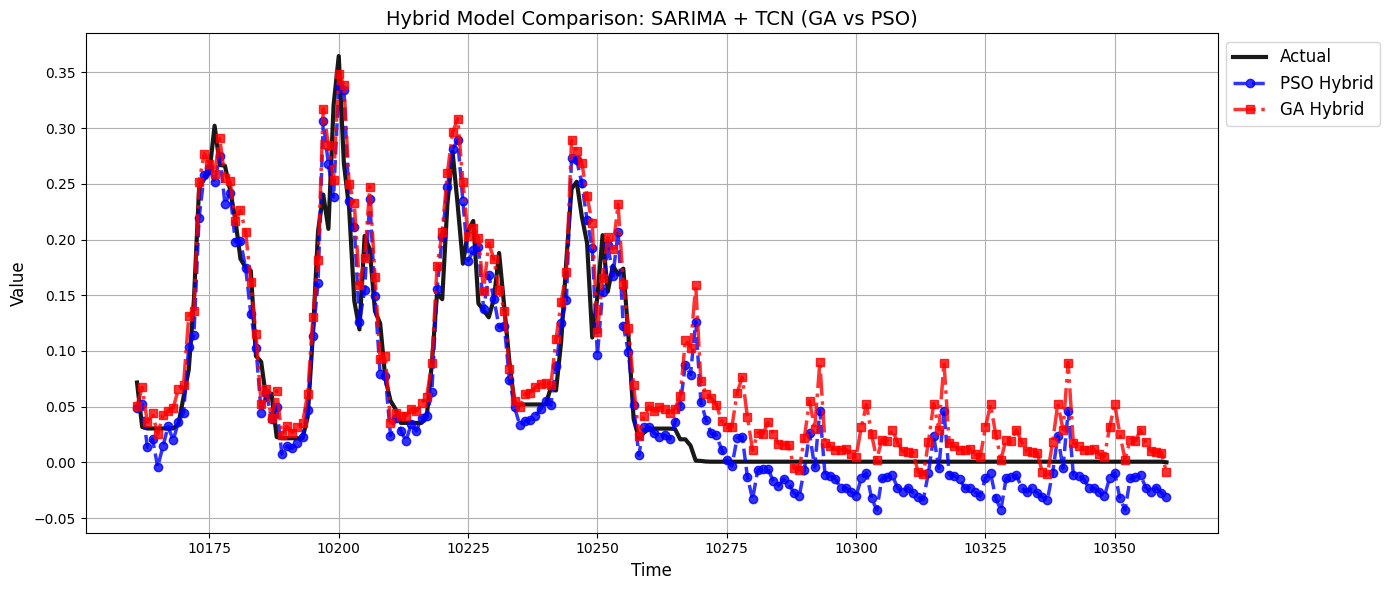

In [17]:
#evaluatioj of both
zoom_points = 200
x_zoom = range(len(actual)-zoom_points, len(actual))

plt.figure(figsize=(14,6))

plt.plot(x_zoom, actual[-zoom_points:], label='Actual',
         color='black', linewidth=3, alpha=0.9)
plt.plot(x_zoom, final_pso[-zoom_points:], label='PSO Hybrid',
         color='blue', linestyle='--', linewidth=2.5,
         marker='o', markersize=6, alpha=0.8)
plt.plot(x_zoom, final_ga[-zoom_points:], label='GA Hybrid',
         color='red', linestyle='-.', linewidth=2.5,
         marker='s', markersize=6, alpha=0.8)

plt.xlabel("Time", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.title("Hybrid Model Comparison: SARIMA + TCN (GA vs PSO)", fontsize=14)
plt.legend(loc='upper left', bbox_to_anchor=(1,1), fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()